# Flood Detection — Sentinel-1 / Sentinel-2 Data Fusion

This notebook converts the Sentinel Hub
[S1 Flooding Visualisation](https://custom-scripts.sentinel-hub.com/custom-scripts/data-fusion/s1_flooding_visualisation/)
custom script by **William Ray & Maxim Lamare** into a reusable openEO
User-Defined Process (UDP).

## Overview

Optical imagery is frequently useless during a flood event because the same
weather systems that cause flooding also bring heavy cloud cover. Sentinel-1's
C-band radar sees through cloud (and at night), so it is the sensor of choice for
rapid flood detection, while Sentinel-2 still provides a familiar, readable
background for interpretation wherever it is available.

The algorithm is a **single-date, multi-sensor fusion**: for each pixel, the
Sentinel-1 VV backscatter is converted to decibels and thresholded — smooth water
surfaces reflect radar energy away from the sensor (specular reflection), so they
return **very low backscatter**. Pixels below the threshold are classified as
flooded/water and rendered in **blue**; every other pixel falls back to the
Sentinel-2 near-infrared background, so the output is a single readable image
rather than two separate ones.

## What the classification produces

| Colour | Meaning | Condition |
| --- | --- | --- |
| **Blue** | flooded / water | Sentinel-1 VV backscatter ≤ `-water_threshold_db` (default -15 dB) |
| **Grayscale (NIR)** | dry land | Sentinel-2 B08, scaled by `background_gain` |

### How the conversion maps to openEO

| Original (custom script) | openEO conversion |
| --- | --- |
| two `datasource`s (`S2L2A`, `S1GRD`), `mosaicking: "SIMPLE"` | two `load_collection` calls, each reduced to one temporal slice with `first` |
| `toDB(input) = 10 * log(input) / LN10` | `openeo.processes.log(x, base=10)` |
| per-pixel `if/else` colour logic | `if_` inside one `apply_dimension` over the bands dimension |
| different S1/S2 grids | `resample_cube_spatial` of S1 onto the S2 grid before merging |
| `lim` / `f` constants | exposed as the `water_threshold_db` / `background_gain` UDP parameters |

## License

- This notebook is a conversion of a Sentinel Hub custom script and is licensed
under **CC-BY-SA-4.0**.
- Original script: https://custom-scripts.sentinel-hub.com/custom-scripts/data-fusion/s1_flooding_visualisation/
- Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)
- Conversion: Development Seed (openEO-UDP project)

## Scientific Background

A radar pulse hitting **calm open water** reflects away from the sensor almost
perfectly (specular reflection at C-band, 5.6 cm wavelength), so very little
energy returns and the pixel is dark in VV backscatter. Nearly every other land
surface is rough enough at this wavelength to scatter some energy back toward the
sensor, so it reads brighter. Flooded land therefore shows up as very low
backscatter, converted here to decibels and compared against a threshold
(`-15 dB` by default) — the same physical basis used across essentially all
operational SAR flood mapping (Ulaby et al., 1982).

Because this is a **single-date** threshold rather than a before/after change
detection, permanently dark surfaces (lakes, rivers, some bare soil, radar
shadow) are also classified as water — this is a known limitation of the
original script, inherited here unchanged (see *Limitations* below).

## Import Required Libraries

In [1]:
from openeo.processes import array_create, if_, log

import rioxarray
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# openEO UDP parameter management system
from openeo_udp import ParameterManager

## Load Parameters and Connect to openEO Backend

We connect to the **Copernicus Data Space Ecosystem (CDSE)**, the backend that
serves both Sentinel-1 GRD (as calibrated linear backscatter) and Sentinel-2
L2A — both are required for the fusion.

In [2]:
# Initialize the algorithm ID for UDP registration
_algorithm_id = "flood_detection"

# Initialize parameter manager
param_manager = ParameterManager("flood_detection.params.py")

# Display available options using the built-in helper
param_manager.print_options("flood detection (S1/S2 fusion) algorithm")

Available parameter sets for flood detection (S1/S2 fusion) algorithm:
  1. thessaly_greece_2023: Thessaly, Greece (2023 Storm Daniel floods)
  2. severn_river_uk_2024: Severn River, UK

Available OpenEO endpoints:
  1. localhost_dev: http://localhost:8082/
  2. ds_development: https://openeo.ds.io/
  3. copernicus_dataspace: https://openeo.dataspace.copernicus.eu/
  4. eopf_explorer: https://api.explorer.eopf.copernicus.eu/openeo

💡 Tip: Use param_manager.interactive_parameter_selection() for interactive selection,
or param_manager.quick_connect('set_name', 'endpoint') for direct connection.
To change selections, use the interactive widgets in the next cell.


In [3]:
# This data-fusion algorithm needs a backend that serves BOTH Sentinel-1 GRD
# (as calibrated linear backscatter) and Sentinel-2 L2A. Keep the endpoint name
# in a variable so the Sentinel-1 collection/bands can be mapped through the
# SAME endpoint mapper used for the Sentinel-2 side below.
endpoint_name = "copernicus_dataspace"
_primary_set = "thessaly_greece_2023"

connection, current_params = param_manager.quick_connect(
    param_set=_primary_set,
    endpoint=endpoint_name,
)

🔄 Connecting to copernicus_dataspace...
📍 Using parameter set: thessaly_greece_2023
Authenticated using refresh token.
✅ Successfully connected to copernicus_dataspace
✅ Parameters loaded and mapped for: Thessaly, Greece (2023 Storm Daniel floods)
🔄 Parameters mapped for endpoint copernicus_dataspace:
  bands: ['b08'] -> ['B08']
  collection: sentinel-2-l2a -> SENTINEL2_L2A


## Load Sentinel-2 and Sentinel-1

Each acquisition is loaded over `bounding_box`, reduced to a single slice with
`first` (the earliest valid observation in the window) — `time_s1` for the SAR
acquisition, `time_s2` for the optical background (the same window for both if
the parameter set doesn't split them).

- **Sentinel-2** — `B08` (near-infrared), filtered by `cloud_cover`, for the
  background. Flows through the standard parameter mapping so
  `reflectance_scale` and the dimension names are injected.
- **Sentinel-1** — `VV`, for water detection. The standard mapping only
  auto-maps the single `collection`/`bands` pair used by Sentinel-2 above, so
  the Sentinel-1 collection/band is routed through the same endpoint mapper
  explicitly via `apply_endpoint_mapping`. A 5x5 averaging kernel
  (`apply_kernel`) is then applied to despeckle the raw backscatter before
  thresholding — see *Fuse the Sensors* below for why.

In [4]:
bbox = current_params["bounding_box"]
time_extent = current_params["time"]
bands_dim = current_params["bands_dimension"]
time_dim = current_params["time_dimension"]
scale = current_params["reflectance_scale"]  # 10000.0 on CDSE

# --- Sentinel-2 optical background ---
s2 = connection.load_collection(
    current_params["collection"].default,
    temporal_extent=time_extent,
    spatial_extent=bbox,
    bands=current_params["bands"].default,
    properties={
        "eo:cloud_cover": lambda x: x <= current_params["cloud_cover"].default,
    },
).reduce_dimension(dimension=time_dim, reducer="last")

# --- Sentinel-1 SAR for water detection ---
_s1 = param_manager.apply_endpoint_mapping(
    {"collection": current_params["s1_collection"], "bands": current_params["s1_bands"]},
    endpoint_name,
)

s1 = connection.load_collection(
    _s1["collection"].default,
    temporal_extent=time_extent,
    spatial_extent=bbox,
    bands=_s1["bands"].default,
).reduce_dimension(dimension=time_dim, reducer="last")

print("Loaded S2 (background) and S1 (water detection)")

Loaded S2 (background) and S1 (water detection)


## Fuse the Sensors into One Cube

Sentinel-1 GRD and Sentinel-2 L2A are not delivered on the same native grid, so
the S1 cube is resampled onto the S2 grid before merging. The two cubes carry
different band names (`B08` vs `VV`), so `merge_cubes` can combine them directly
— no band-collision workaround is needed here.

In [5]:
s1_aligned = s1.resample_cube_spatial(s2, method="near")
fused = s2.merge_cubes(s1_aligned)

# The classification reads bands positionally; the order is fixed by
# construction: the Sentinel-2 band(s) (load order) followed by VV.
fused_bands = fused.metadata.band_names
print("Fused band order:", fused_bands)
assert fused_bands[-1].lower() == "vv", f"expected VV last, got {fused_bands}"
assert len(fused_bands) == 2, f'expected 2 fused bands, got {fused_bands}'

Fused band order: ['B08', 'VV']


## Reference Implementation (NumPy)

Before running the classification as an openEO process graph, this section
reproduces the original `evaluatePixel()` logic directly in NumPy — on the
exact same fused data (same `bounding_box`, and `time`) that the openEO 
graph below will classify. It's a fast, independent reference: 
a place to sanity-check `water_threshold_db` and `background_gain` 
against a quick local computation before committing to the
full `save_result`/`download` round-trip on the final composite,
and a numerical baseline the `apply_dimension` classification below should
match.

In [ ]:
# Location slug reused for every download in this notebook.
_location_slug = current_params["location_name"].split(",")[0].strip().lower().replace(" ", "_")

# Pull the fused (pre-classification) bands down as a raster so NumPy can
# read them directly.
fused_raw_filename = f"{_algorithm_id}_{_location_slug}_fused_raw.tif"
fused_raw = param_manager.resolve(fused.save_result("GTiff"), current_params)
fused_raw.download(fused_raw_filename)
print(f"Downloaded {fused_raw_filename}")

### Backscatter/Reflectance Unit Guard

`toDB`, `VV*10`/`VV*50`, and `background_gain * B08` all assume specific
units — calibrated linear backscatter for `VV`, 0-1 reflectance for `B08`
after dividing by `reflectance_scale`. If a backend served decibels, raw
digital numbers, or the wrong `reflectance_scale`, every threshold and gain
in this notebook would silently produce nonsense (e.g. an all-blue or
all-white composite) rather than an obvious error. This check fails loudly
instead, before either the NumPy or the openEO classification runs.

In [7]:
# --- Unit check: confirm VV/B08 are in the units this algorithm assumes -----
# (calibrated linear backscatter for VV, 0-1 reflectance for B08 after scaling)
fused_ds = rioxarray.open_rasterio(fused_raw_filename)
# Band order matches the assertion in "Fuse the Sensors": B08 then VV.
b08_raw, vv_raw = fused_ds.values.astype("float64")
if fused_ds.rio.nodata is not None and np.isfinite(fused_ds.rio.nodata):
    b08_raw[b08_raw == fused_ds.rio.nodata] = np.nan
    vv_raw[vv_raw == fused_ds.rio.nodata] = np.nan

b08_np = b08_raw / scale
vv_np = vv_raw

# Every band must be present for a pixel to be comparable.
valid = np.isfinite(b08_np) & np.isfinite(vv_np)
print(f"comparable pixels: {valid.mean():.2%}")

# Linear backscatter is non-negative and sits mostly below 1; only strong
# double-bounce targets (e.g. flooded buildings) exceed it, so test a high
# percentile rather than the max.
_vv99 = float(np.nanpercentile(vv_np[valid], 99))
assert np.nanmin(vv_np[valid]) >= 0, (
    "Sentinel-1 VV contains negative values, so this backend serves decibels "
    "rather than linear backscatter. The toDB conversion and the VV*10/VV*50 "
    "output terms assume linear; convert with 10**(dB/10) or use a backend "
    "serving linear backscatter (CDSE does)."
)
assert _vv99 <= 5.0, (
    f"Sentinel-1 VV 99th percentile is {_vv99:.1f}, far outside the 0-1 range of "
    "calibrated linear backscatter -- this backend appears to serve raw Level-1 "
    "digital numbers, which would blow the -water_threshold_db test and the "
    "VV*10/VV*50 output terms out of range. Use a backend serving calibrated "
    "backscatter (CDSE does)."
)

# Reflectance after scaling must land in 0-1 (a little over 1 for specular
# glint / bright targets like sand or cloud).
_b08_99 = float(np.nanpercentile(b08_np[valid], 99))
assert 0 <= _b08_99 <= 1.5, (
    f"Sentinel-2 B08 99th percentile is {_b08_99:.2f} after dividing by "
    f"reflectance_scale={scale}. Expected roughly 0-1 reflectance; the scale "
    "for this backend looks wrong, which would corrupt the background "
    "brightness."
)
print(f"✅ Units check out -- VV p99 {_vv99:.3f}, B08 reflectance p99 {_b08_99:.3f}")

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

comparable pixels: 99.83%
✅ Units check out -- VV p99 0.841, B08 reflectance p99 0.468


NumPy reference: 21.4% of pixels classified as water (threshold 15 dB)


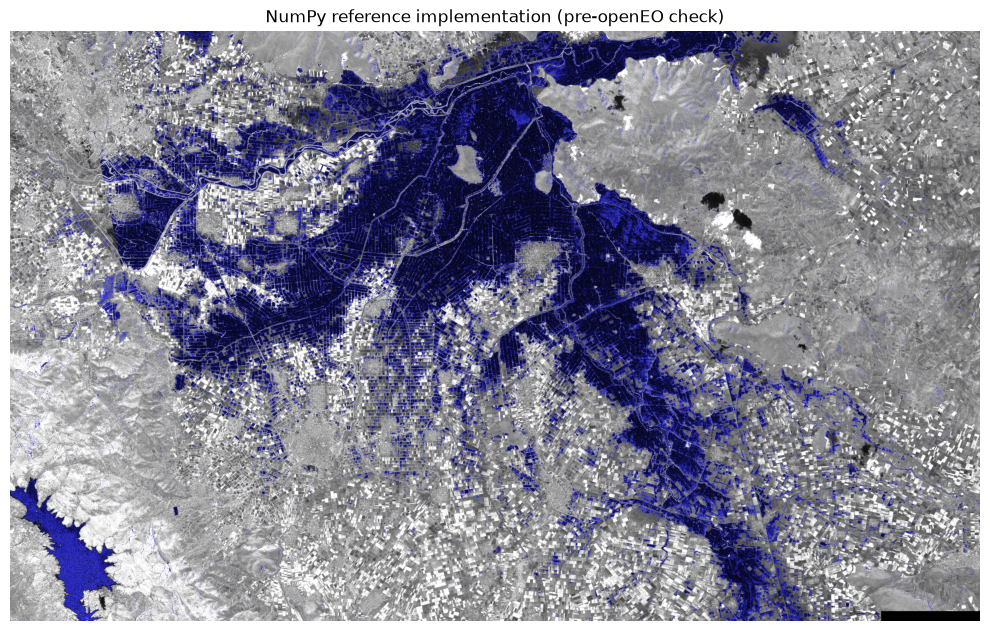

In [8]:
water_threshold_db = current_params["water_threshold_db"].default
background_gain = current_params["background_gain"].default

with np.errstate(divide="ignore", invalid="ignore"):
    vv_db_np = (10 * np.log10(vv_np))
is_water_np = vv_db_np <= -water_threshold_db

red_np = np.where(is_water_np, vv_np * 10, background_gain * b08_np)
green_np = np.where(is_water_np, vv_np * 10, background_gain * b08_np)
blue_np = np.where(is_water_np, vv_np * 50, background_gain * b08_np)
rgb_np = np.clip(np.stack([red_np, green_np, blue_np], axis=-1), 0, 1)
rgb_np[~valid] = np.nan

water_fraction_np = float(np.nanmean(is_water_np[valid]))
print(
    f"NumPy reference: {water_fraction_np:.1%} of pixels classified as water "
    f"(threshold {water_threshold_db} dB)"
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(np.nan_to_num(rgb_np))
ax.set_title("NumPy reference implementation (pre-openEO check)")
ax.axis("off")
plt.tight_layout()
plt.show()

## Per-Pixel Classification

A single `apply_dimension` over the bands dimension runs the original
`evaluatePixel` logic. The callback receives the 2 fused band values (`B08`
then `VV`) and returns a grayscale image with a blue tint over water. 

Faithful to the original:

- `toDB(x) = 10 * log10(x)`, computed here with `openeo.processes.log(x, base=10)`.
- Sentinel-2 reflectance is divided by `reflectance_scale` (10000 on CDSE) to
  match the original's 0-1 input range; Sentinel-1 backscatter is used as-is
  (linear, as served by CDSE).
- `if VV_dB <= -water_threshold_db: [VV*10, VV*10, VV*50]` — red and green are
  equal, blue is boosted, giving flooded pixels a blue tint.
- `else: [gain*B08, gain*B08, gain*B08]` — all three channels equal, i.e. plain
  grayscale for dry land.

In [9]:
def classify(data):
    # Bands in fused order: B08 (Sentinel-2), VV (Sentinel-1).
    b08 = data[0] / scale
    vv = data[1]

    vv_db = 10 * log(vv, base=10)
    is_water = vv_db <= (-1 * water_threshold_db)

    red = if_(is_water, vv * 10, background_gain * b08)
    green = if_(is_water, vv * 10, background_gain * b08)
    blue = if_(is_water, vv * 50, background_gain * b08)
    return array_create([red, green, blue])


flood_rgb = fused.apply_dimension(dimension=bands_dim, process=classify)

## Apply and Export

Save the 3-band classification/visualization as a GeoTIFF.

In [10]:
flood_result = flood_rgb.save_result("GTiff")

## Download and Visualize Results

Download the composite and display it. The output mixes a continuous NIR
background with the flat blue water classification, so we render it directly as
an RGB image.

In [11]:
# Synchronous execution (POST /result) does not accept unresolved Parameter refs,
# so materialize them with the current parameter set's defaults before download.
# (_location_slug was already computed in the NumPy reference section above.)
filename = f"{_algorithm_id}_{_location_slug}.tif"

resolved = param_manager.resolve(flood_result, current_params)
resolved.download(filename)
print(f"Downloaded {filename}")

Downloaded flood_detection_thessaly.tif


openEO result: 21.3% of pixels classified as water (threshold 15 dB)


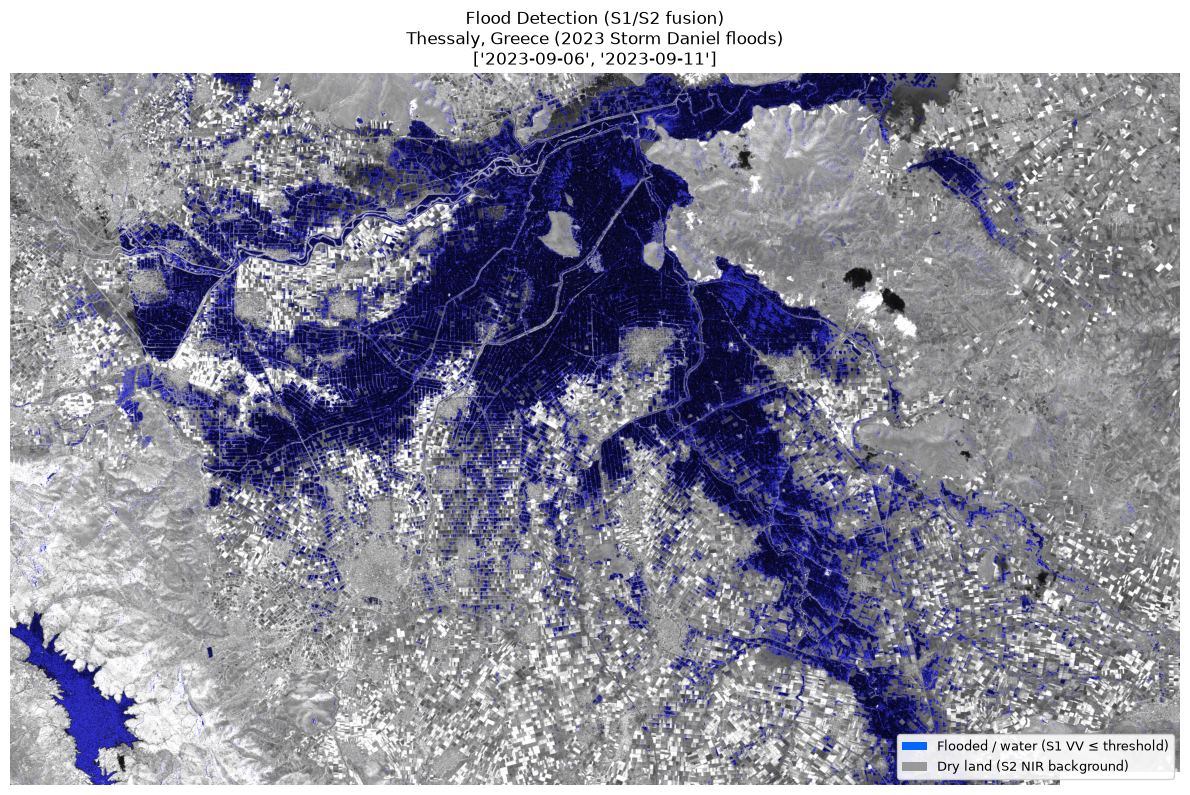

In [ ]:
# Open the 3-band result and display it as an RGB image.
ds = rioxarray.open_rasterio(filename)

rgb_img = ds.transpose("y", "x", "band").values.astype("float32")
rgb_img = np.clip(rgb_img, 0, 1)

# Water fraction from the openEO composite
_nodata = ds.rio.nodata
_valid_mask = np.ones(rgb_img.shape[:2], dtype=bool)
if _nodata is not None and np.isfinite(_nodata):
    _valid_mask = ~np.any(ds.values == _nodata, axis=0)

is_water_openeo = rgb_img[..., 2] > rgb_img[..., 0]
water_fraction_openeo = float(np.mean(is_water_openeo[_valid_mask]))
print(
    f"openEO result: {water_fraction_openeo:.1%} of pixels classified as water "
    f"(threshold {current_params['water_threshold_db'].default} dB)"
)

preview_fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(
    rgb_img,
    extent=[ds.x.values.min(), ds.x.values.max(), ds.y.values.min(), ds.y.values.max()],
)
ax.set_title(
    f"Flood Detection (S1/S2 fusion)\n{current_params['location_name']}\n"
    f"{current_params["time"].default}",
    fontsize=12,
)

legend = [
    Patch(facecolor=(0, 0.4, 1), label="Flooded / water (S1 VV ≤ threshold)"),
    Patch(facecolor=(0.6, 0.6, 0.6), label="Dry land (S2 NIR background)"),
]
ax.legend(handles=legend, loc="lower right", fontsize=9, framealpha=0.9)
ax.axis("off")
plt.tight_layout()
plt.show()

## Pre-/During-/Post-Flood Comparison (Thessaly, Greece)

`thessaly_greece_2023` also defines `time_pre` (a baseline window before Storm
Daniel) and `time_post` (a recession-check window afterward) in the parameter
file, alongside the main `time` window already used for the flood-date
composite above. This section reruns the identical fusion/classification
pipeline for those two extra windows, downloads both results, and plots
pre-/during-/post-flood side by side so the flood's onset and recession are
directly comparable.

In [ ]:
def run_flood_composite(time_param, label):
    """Rerun the same S1+S2 fusion/classification pipeline for a different time window."""
    _s2 = connection.load_collection(
        current_params["collection"].default,
        temporal_extent=time_param,
        spatial_extent=bbox,
        bands=current_params["bands"].default,
        properties={
            "eo:cloud_cover": lambda x: x <= current_params["cloud_cover"].default,
        },
    ).reduce_dimension(dimension=time_dim, reducer="last")

    _s1_cube = connection.load_collection(
        _s1["collection"].default,
        temporal_extent=time_param,
        spatial_extent=bbox,
        bands=_s1["bands"].default,
    ).reduce_dimension(dimension=time_dim, reducer="last")

    _s1_aligned = _s1_cube.resample_cube_spatial(_s2, method="near")
    _fused = _s2.merge_cubes(_s1_aligned)
    _rgb = _fused.apply_dimension(dimension=bands_dim, process=classify)

    _out_filename = f"{_algorithm_id}_{_location_slug}_{label}.tif"
    _resolved = param_manager.resolve(_rgb.save_result("GTiff"), current_params)
    _resolved.download(_out_filename)
    print(f"Downloaded {_out_filename}")
    return _out_filename


def _read_rgb(path):
    _ds = rioxarray.open_rasterio(path)
    _img = _ds.transpose("y", "x", "band").values.astype("float32")
    return np.clip(_img, 0, 1), _ds

In [ ]:
pre_filename = run_flood_composite(current_params["time_pre"], "pre")
post_filename = run_flood_composite(current_params["time_post"], "post")

# Restore the primary parameter set for the export section below.
param_manager.use_parameter_set(_primary_set)

Downloaded flood_detection_thessaly_pre.tif
Downloaded flood_detection_thessaly_post.tif


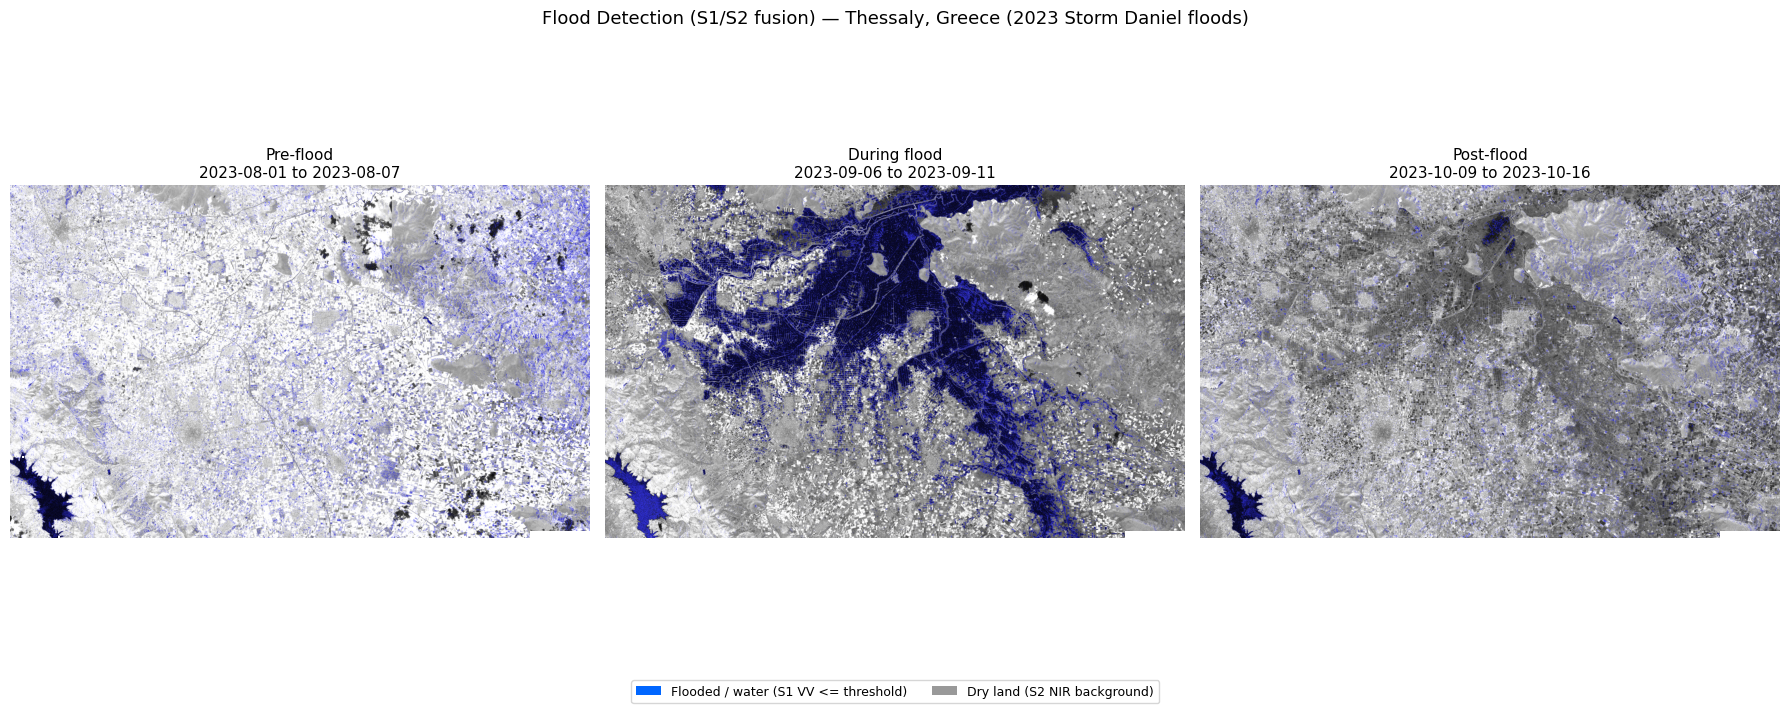

In [ ]:
# Reuse "filename" (the during-flood composite already downloaded above) so
# only the pre/post windows need a fresh download.
panels = [
    ("Pre-flood", pre_filename, current_params["time_pre"].default),
    ("During flood", filename, current_params["time"].default),
    ("Post-flood", post_filename, current_params["time_post"].default),
]

flood_development_fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, (label, path, window) in zip(axes, panels):
    img, ds = _read_rgb(path)
    ax.imshow(
        img,
        extent=[ds.x.values.min(), ds.x.values.max(), ds.y.values.min(), ds.y.values.max()],
    )
    ax.set_title(f"{label}\n{window[0]} to {window[1]}", fontsize=11)
    ax.axis("off")

legend = [
    Patch(facecolor=(0, 0.4, 1), label="Flooded / water (S1 VV <= threshold)"),
    Patch(facecolor=(0.6, 0.6, 0.6), label="Dry land (S2 NIR background)"),
]
flood_development_fig.legend(handles=legend, loc="lower center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.02))
flood_development_fig.suptitle(f"Flood Detection (S1/S2 fusion) \u2014 {current_params['location_name']}", fontsize=13)
plt.tight_layout()
plt.show()

## Validate for Severn River, UK

Reuse `run_flood_composite` to confirm the same classification
pipeline runs end-to-end for a second location. `run_flood_composite`
reads `connection`, `current_params`, `bbox`, `_s1`, `bands_dim`,
`time_dim` and `scale` from the enclosing scope rather than taking
them as arguments, so this cell rebinds those globals to the
`severn_river_uk_2024` parameter set before calling it, then restores
`thessaly_greece_2023` afterwards so the export section below still
targets the intended primary set.

In [12]:
_severn_set = "severn_river_uk_2024"

# Rebind the globals `run_flood_composite` reads to the Severn parameter set.
connection, current_params = param_manager.quick_connect(
    param_set=_severn_set,
    endpoint=endpoint_name,
)
bbox = current_params["bounding_box"]
bands_dim = current_params["bands_dimension"]
time_dim = current_params["time_dimension"]
scale = current_params["reflectance_scale"]
_s1 = param_manager.apply_endpoint_mapping(
    {"collection": current_params["s1_collection"], "bands": current_params["s1_bands"]},
    endpoint_name,
)
_location_slug = current_params["location_name"].split(",")[0].strip().lower().replace(" ", "_")

# Keep the Severn windows around (as plain values, not Parameter objects) so
# the comparison plot below can label panels without depending on whichever
# parameter set happens to be active by the time it runs.
severn_windows = {
    "pre": current_params["time_pre"].default,
    "during": current_params["time"].default,
    "post": current_params["time_post"].default,
}

severn_pre_filename = run_flood_composite(current_params["time_pre"], "pre")
severn_during_filename = run_flood_composite(current_params["time"], "during")
severn_post_filename = run_flood_composite(current_params["time_post"], "post")

print("Severn River validation complete:")
print(f"  pre:    {severn_pre_filename}")
print(f"  during: {severn_during_filename}")
print(f"  post:   {severn_post_filename}")

# Restore Thessaly as the primary set for the export section below.
connection, current_params = param_manager.quick_connect(
    param_set=_primary_set,
    endpoint=endpoint_name,
)
bbox = current_params["bounding_box"]
_location_slug = current_params["location_name"].split(",")[0].strip().lower().replace(" ", "_")

🔄 Connecting to copernicus_dataspace...
📍 Using parameter set: severn_river_uk_2024
Authenticated using refresh token.
✅ Successfully connected to copernicus_dataspace
✅ Parameters loaded and mapped for: Severn River, UK
🔄 Parameters mapped for endpoint copernicus_dataspace:
  bands: ['b08'] -> ['B08']
  collection: sentinel-2-l2a -> SENTINEL2_L2A
Downloaded flood_detection_severn_river_pre.tif
Downloaded flood_detection_severn_river_during.tif
Downloaded flood_detection_severn_river_post.tif
Severn River validation complete:
  pre:    flood_detection_severn_river_pre.tif
  during: flood_detection_severn_river_during.tif
  post:   flood_detection_severn_river_post.tif
🔄 Connecting to copernicus_dataspace...
📍 Using parameter set: thessaly_greece_2023
Authenticated using refresh token.
✅ Successfully connected to copernicus_dataspace
✅ Parameters loaded and mapped for: Thessaly, Greece (2023 Storm Daniel floods)
🔄 Parameters mapped for endpoint copernicus_dataspace:
  bands: ['b08'] -> 

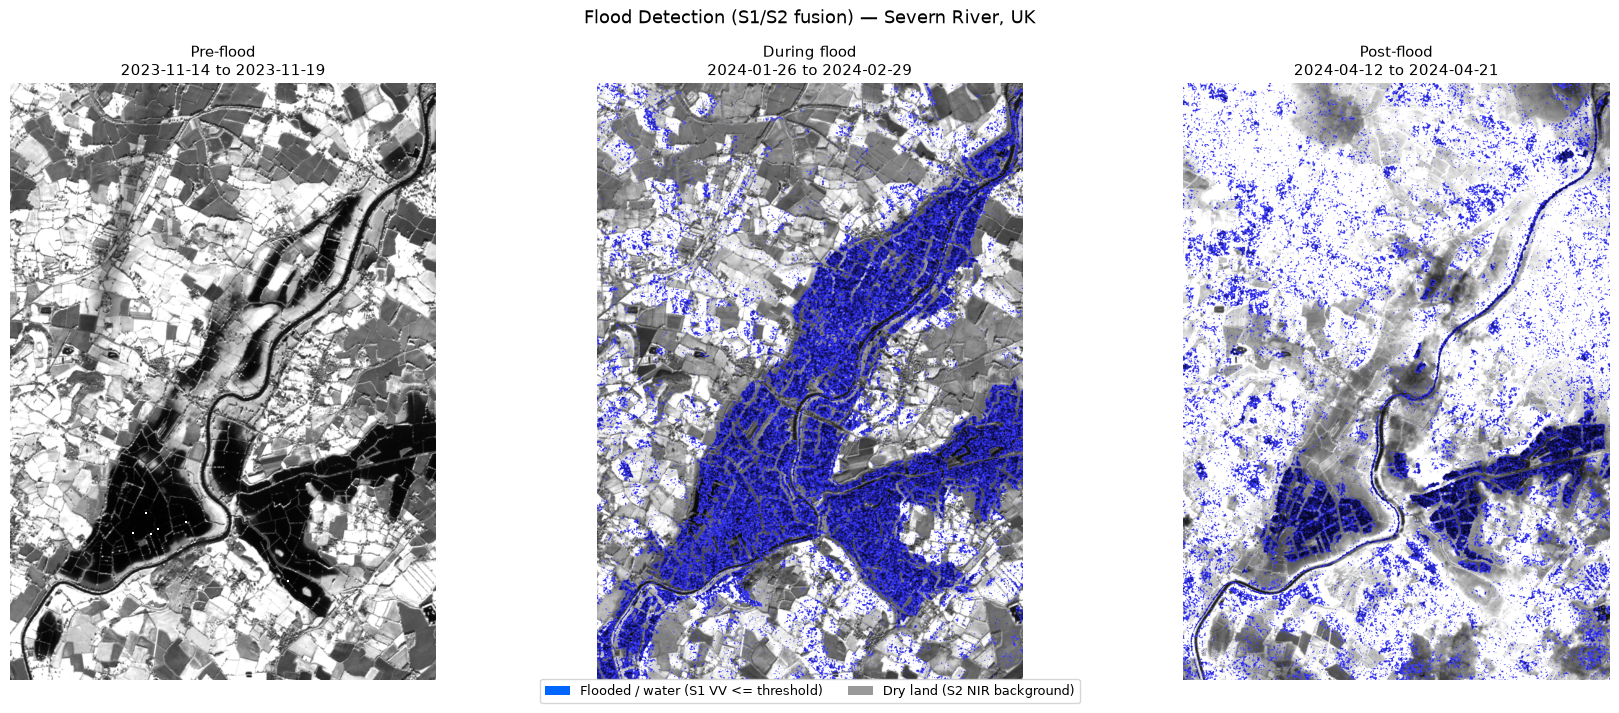

In [15]:
severn_panels = [
    ("Pre-flood", severn_pre_filename, severn_windows["pre"]),
    ("During flood", severn_during_filename, severn_windows["during"]),
    ("Post-flood", severn_post_filename, severn_windows["post"]),
]

severn_development_fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, (label, path, window) in zip(axes, severn_panels):
    img, ds = _read_rgb(path)
    ax.imshow(
        img,
        extent=[ds.x.values.min(), ds.x.values.max(), ds.y.values.min(), ds.y.values.max()],
    )
    ax.set_title(f"{label}\n{window[0]} to {window[1]}", fontsize=11)
    ax.axis("off")

legend = [
    Patch(facecolor=(0, 0.4, 1), label="Flooded / water (S1 VV <= threshold)"),
    Patch(facecolor=(0.6, 0.6, 0.6), label="Dry land (S2 NIR background)"),
]
severn_development_fig.legend(handles=legend, loc="lower center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.02))
severn_development_fig.suptitle("Flood Detection (S1/S2 fusion) — Severn River, UK", fontsize=13)
plt.tight_layout()
plt.show()

## Interpretation Guide and Limitations

### Reading the result

- **Blue** pixels are the key output: locations where Sentinel-1 VV backscatter
  fell at or below the water threshold, read as flooded or standing water.
- The **grayscale background** is the Sentinel-2 near-infrared band, providing
  spatial context (vegetation, urban areas, bare ground) wherever cloud-free
  optical data was available.

### Limitations and differences from the original

- **CDSE-only.** The fusion needs both Sentinel-1 GRD (as calibrated linear
  backscatter) and Sentinel-2 L2A; CDSE is the backend that serves both.
- **Single-date threshold, not change detection.** Like the original script,
  this classifies water from *one* Sentinel-1 acquisition rather than comparing
  before/during-flood dates. Permanently dark surfaces — lakes, rivers, some
  bare or wet soils, and radar shadow in hilly terrain — are also classified as
  "flooded" even outside a flood event. A bi-temporal approach (see the
  companion
  [`flood_mapping`](../../sentinel-1/water_and_flood_monitoring/flood_mapping.ipynb)
  notebook) removes this ambiguity by comparing two dates instead.
- **Backscatter convention.** Sentinel-1 GRD on CDSE is loaded as calibrated
  linear backscatter, matching the original's linear VV terms in the water
  branch (`VV*10`, `VV*50`). If a backend returns dB or an uncalibrated digital
  number instead, both the `toDB` conversion and the output scaling would need
  to change.
- **Temporal window reduced with `last`.** The `time` window is collapsed to
  one slice per sensor by taking the most recent valid observation — chosen to
  approximate the original script's `SIMPLE` mosaicking, whose default
  ordering is "most recent" rather than "first available." A window spanning
  multiple distinct passes only uses the latest one, discarding any earlier
  scene. `bounding_box`, `time`, `cloud_cover`, `water_threshold_db` and
  `background_gain` are the runtime knobs.
- **No SCL/cloud masking on the background.** Cloudy Sentinel-2 pixels are only
  filtered at the scene level via `cloud_cover`, not pixel level — a partly
  cloudy scene can still show clouds in the non-water background, the same
  behaviour as the original script.
- **Grid alignment.** S1 is resampled onto the S2 grid with nearest-neighbour
  before merging; minor co-registration differences between sensors are not
  corrected.

## Export the Process Graph

The exported UDP is the **RGB flood-visualization composite**. Its parameters
are the runtime knobs — area of interest, time window, cloud-cover tolerance,
and the two tunable thresholds (`water_threshold_db`, `background_gain`) —
while the collections and bands stay intrinsic to the algorithm.

In [21]:
# Notebook metadata used to build the OGC API record. Tagged so
# `populate_record.py` can find and `exec()` this cell by tag, not position --
# which means it runs with its own fresh globals, so everything it needs is
# recomputed here rather than referencing state from earlier cells.
from pathlib import Path

from openeo_udp import ParameterManager
from openeo_udp.endpoints import get_endpoint_config

_algorithm_id = "flood_detection"

_repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "notebooks").exists())
_nb_href = f"{(Path.cwd() / f'{_algorithm_id}.ipynb').relative_to(_repo_root)}"

_param_set = "thessaly_greece_2023"
_endpoint_name = "copernicus_dataspace"
_param_manager = ParameterManager(f"{_algorithm_id}.params.py")
_raw_params = _param_manager.get_parameter_set(_param_set)

# Endpoint mapping resolves the backend-native collection id (which can differ
# from the canonical id in the .params.py file), matching what the earlier
# cells actually load via quick_connect().
_mapped_params = _param_manager.apply_endpoint_mapping(_raw_params, _endpoint_name)
_endpoint_config = get_endpoint_config(_endpoint_name)

# Notebook metadata
metadata = {
    "id": _algorithm_id,
    "title": "Flood Detection (S1/S2 Fusion)",
    "preview_title": "Flood Detection (S1/S2 Fusion)",
    "description": (
        "Single-date Sentinel-1/Sentinel-2 data fusion that visualizes flood "
        "extent under cloud cover by thresholding Sentinel-1 VV backscatter "
        "and compositing the result over a Sentinel-2 near-infrared background."
    ),
    "keywords": ["Natural Hazards", "Radar", "Sentinel-1", "Sentinel-2", "Change Detection Services"],
    "themes": ["FLOODS", "DISASTER MONITORING", "REMOTE SENSING", "Sentinel-1 SAR", "Sentinel-2 MSI"],
    "created": "2026-08-10T00:00:00Z",
    "updated": "2026-08-10T00:00:00Z",
    "license": "CC-BY-SA-4.0",
    "openeo_backend_title": _endpoint_config["name"],
    "openeo_backend_url": _endpoint_config["url"],
    "notebook_github_location": _nb_href,
    "collection_id": _mapped_params["collection"].default,
    "attribution": {
        "original_script": "https://custom-scripts.sentinel-hub.com/custom-scripts/data-fusion/s1_flooding_visualisation/",
        "authors": ["William Ray", "Maxim Lamare"],
        "source_repository": "https://github.com/sentinel-hub/custom-scripts",
        "citation": None
    },
}

In [22]:
# Export the process graph for reuse
import json

from algorithm_registration.register_algorithm import register

process_graph = {
    "process_graph": flood_result.flat_graph(),
    "parameters": [
        current_params["bounding_box"].to_dict(),
        current_params["time"].to_dict(),
        current_params["cloud_cover"].to_dict(),
        current_params["water_threshold_db"].to_dict(),
        current_params["background_gain"].to_dict(),
    ],
    "id": _algorithm_id,
    "summary": "Sentinel-1/Sentinel-2 flood visualization using openEO.",
    "description": (
        "Fuses a single-date Sentinel-1 VV backscatter threshold with a "
        "Sentinel-2 near-infrared background to visualize flood extent under "
        "cloud cover. Flooded/water pixels (VV backscatter at or below "
        "-water_threshold_db) are rendered in blue; all other pixels fall back "
        "to the scaled Sentinel-2 background. Converted from the Sentinel Hub "
        "S1 Flooding Visualisation custom script by William Ray & Maxim Lamare."
    ),
}

# Save the process graph
udp_path = Path(f"{_algorithm_id}.json")
with open(udp_path, "w") as f:
    json.dump(process_graph, f, indent=2)

register(
    notebook_path=Path.cwd() / f"{_algorithm_id}.ipynb",
    udp_path=Path(f"{_algorithm_id}.json"),
    preview_fig=preview_fig
)

Algorithm directory: /Users/firzariany/Documents/code/openeo-udp/algorithm_registration/flood_detection
UDP registered: /Users/firzariany/Documents/code/openeo-udp/algorithm_registration/flood_detection/openeo_udp/flood_detection.json
Preview registered from figure: /Users/firzariany/Documents/code/openeo-udp/algorithm_registration/flood_detection/records/preview.png
Notebook : /Users/firzariany/Documents/code/openeo-udp/notebooks/sentinel/sentinel-2/marine_and_water_bodies/flood_detection.ipynb
Template : /Users/firzariany/Documents/code/openeo-udp/algorithm_registration/records_template.json
Metadata extracted — id: 'flood_detection'
Record written: /Users/firzariany/Documents/code/openeo-udp/algorithm_registration/flood_detection/records/flood_detection.json
Thumbnail written: /Users/firzariany/Documents/code/openeo-udp/algorithm_registration/flood_detection/records/thumbnail.png
Commit all the records before pushing to openeo-udp repository


PosixPath('/Users/firzariany/Documents/code/openeo-udp/algorithm_registration/flood_detection')

## References and Attribution

**Original Script:** [S1 Flooding Visualisation](https://custom-scripts.sentinel-hub.com/custom-scripts/data-fusion/s1_flooding_visualisation/)

**Authors:** William Ray & Maxim Lamare

**Source Repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

### Scientific references

- Ulaby, F. T., Moore, R. K., Fung, A. K. (1982). *Microwave Remote Sensing:
  Active and Passive, Vol. II.* Addison-Wesley. — the specular-reflection
  behaviour of smooth water at microwave wavelengths.

### openEO Conversion
- **Conversion Date**: 10 August 2026
- **openEO Framework**: Adapted for the openEO API and process graph structure
- **Backend Tested**: CDSE (Copernicus Data Space Ecosystem)
- **License**: CC-BY-SA-4.0

## Conclusion

This notebook converts the S1 Flooding Visualisation algorithm into an openEO
User-Defined Process. The implementation:

✅ **Fuses two sensors** (Sentinel-1 VV, Sentinel-2 B08) using
`resample_cube_spatial` for grid alignment and `merge_cubes` for the fusion.

✅ **Reproduces the per-pixel classification** with `if_` and a decibel
threshold, preserving the original's two output states and default constants
(`lim=15`, `f=2.5`) as tunable UDP parameters.

✅ **Follows openEO standards** with an exported, parameterized process graph and
catalogue metadata.

### Key conversion notes
- `bounding_box`, `time`, `cloud_cover`, `water_threshold_db` and
  `background_gain` are the UDP parameters; collections and bands are intrinsic
  to the algorithm.
- Targets CDSE because it serves both Sentinel-1 GRD (calibrated) and
  Sentinel-2 L2A.